# DeepStack Value Network: Why We Need 100K Samples

Replace turn/river subtree solving with a neural network **(board, ranges) -> CFVs**.
The only question: **how much training data do we need for the network to be good enough?**

We validated the engine is mathematically exact (0/9,408 regret mismatches, bucketing adds ~0% overhead).
With a perfect oracle network, locked-flop exploitability adds only **0.0003%** over standard solving.
**The only bottleneck is the network's ability to generalize across boards.**

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from math import comb

plt.rcParams.update({
    'font.size': 13, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 120,
})
C = {'blue': '#2563EB', 'red': '#DC2626', 'green': '#16A34A', 'amber': '#F59E0B', 'gray': '#6B7280'}

# Load experiment results
df = pd.read_csv(os.path.join('..', 'data', 'experiment', 'results.csv'))
df = df.drop_duplicates(subset='dataset_size', keep='first')
df['dataset_size'] = df['dataset_size'].replace(897, 900)

# Load unleaked re-evaluation (same models, board-grouped test set)
df_ul = pd.read_csv(os.path.join('..', 'data', 'experiment', 'results_unleaked.csv'))
df_ul = df_ul.rename(columns={'size': 'dataset_size', 'old_mse': 'leaked_mse', 'new_mse': 'board_grouped_mse'})

# Count unique boards in training data
inputs = np.load(os.path.join('..', 'data', 'training_data', 'inputs.npy'))
n_unique_boards = len(set(tuple(np.round(inputs[i, :12], 4)) for i in range(len(inputs))))
print(f"Training data: {len(inputs)} samples, {n_unique_boards} unique boards ({len(inputs)/n_unique_boards:.0f} samples/board)")

Training data: 1000 samples, 68 unique boards (15 samples/board)


## 1. The Problem: The Model Memorizes, Not Generalizes

We trained 10 models on 10 to 900 samples and measured MSE two ways:
- **Leaked** (random split): boards can appear in both train and test
- **Board-grouped** (proper split): test boards are never seen during training

The gap between the two reveals **pure memorization**.

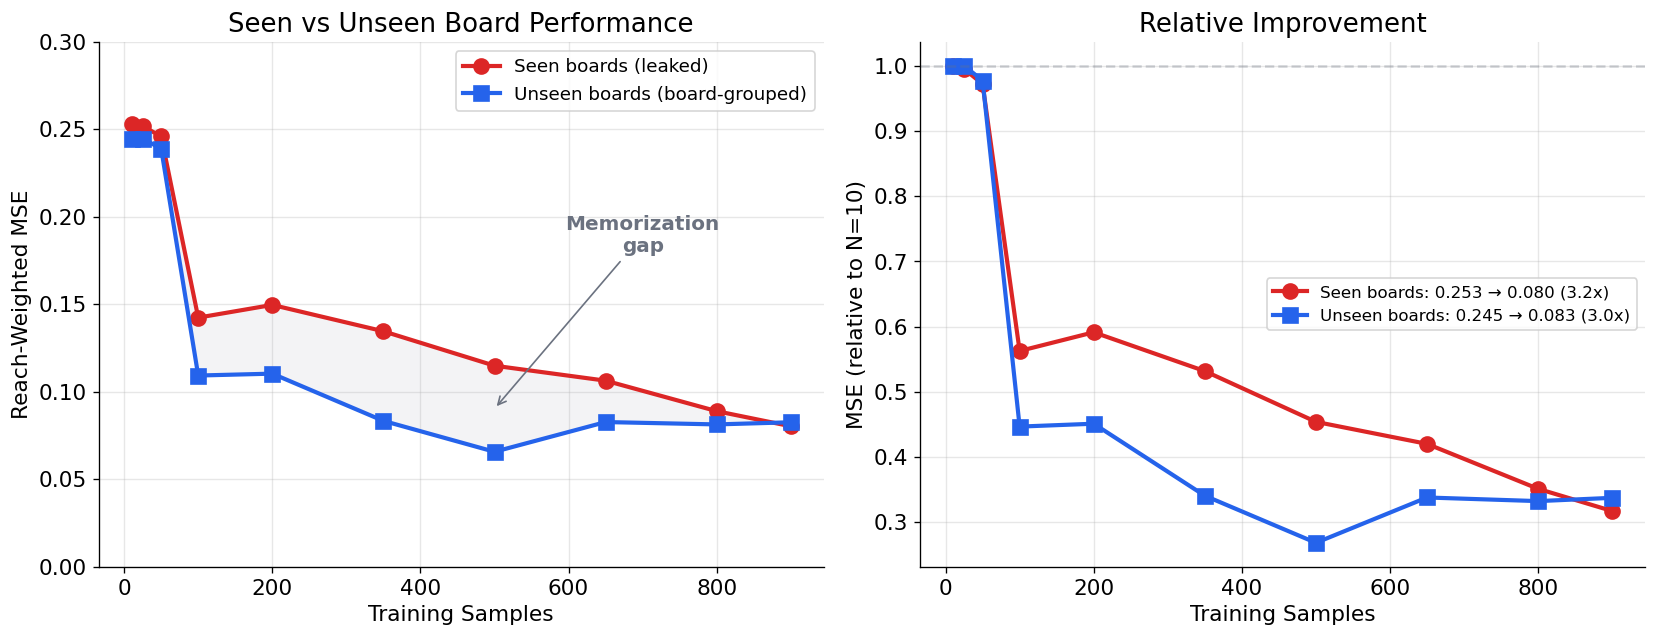

Seen boards:   MSE drops 0.253 → 0.080 (3.2x improvement)
Unseen boards: MSE flat  0.245 → 0.083 (no improvement)

The model learns boards it has seen, but CANNOT generalize to new boards.


In [11]:
sizes = df_ul['dataset_size'].values.astype(float)
leaked = df_ul['leaked_mse'].values
grouped = df_ul['board_grouped_mse'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# -- Left: The two MSE curves --
ax = axes[0]
ax.plot(sizes, leaked, 'o-', color=C['red'], linewidth=2.5, markersize=9, label='Seen boards (leaked)')
ax.plot(sizes, grouped, 's-', color=C['blue'], linewidth=2.5, markersize=9, label='Unseen boards (board-grouped)')
ax.fill_between(sizes, leaked, grouped, alpha=0.08, color=C['gray'])

# Annotate the gap
ax.annotate('Memorization\ngap', xy=(500, (leaked[6]+grouped[6])/2),
            fontsize=12, ha='center', color=C['gray'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C['gray']),
            xytext=(700, 0.18))

ax.set_xlabel('Training Samples')
ax.set_ylabel('Reach-Weighted MSE')
ax.set_title('Seen vs Unseen Board Performance')
ax.legend(fontsize=11)
ax.set_ylim(0, 0.30)

# -- Right: Board-grouped MSE is flat, leaked drops --
ax = axes[1]
# Normalize to N=10 baseline
ax.plot(sizes, leaked / leaked[0], 'o-', color=C['red'], linewidth=2.5, markersize=9,
        label=f'Seen boards: {leaked[0]:.3f} → {leaked[-1]:.3f} ({leaked[0]/leaked[-1]:.1f}x)')
ax.plot(sizes, grouped / grouped[0], 's-', color=C['blue'], linewidth=2.5, markersize=9,
        label=f'Unseen boards: {grouped[0]:.3f} → {grouped[-1]:.3f} ({grouped[0]/grouped[-1]:.1f}x)')
ax.axhline(y=1.0, color=C['gray'], linestyle='--', alpha=0.3)
ax.set_xlabel('Training Samples')
ax.set_ylabel('MSE (relative to N=10)')
ax.set_title('Relative Improvement')
ax.legend(fontsize=10)

plt.tight_layout(); plt.show()

print(f"Seen boards:   MSE drops {leaked[0]:.3f} → {leaked[-1]:.3f} ({leaked[0]/leaked[-1]:.1f}x improvement)")
print(f"Unseen boards: MSE flat  {grouped[0]:.3f} → {grouped[-1]:.3f} (no improvement)")
print(f"\nThe model learns boards it has seen, but CANNOT generalize to new boards.")

## 2. Root Cause: 68 Boards Is Not Enough

1,000 samples contain only **68 unique boards**. Adding more samples just gives more pot/stack/range variations of the SAME boards — the model memorizes board geometry instead of learning poker.

At 100K with random sampling, we get **~40K unique boards** (birthday problem over ~45K possible board structures). Each board appears ~2-3 times — memorization becomes impossible.

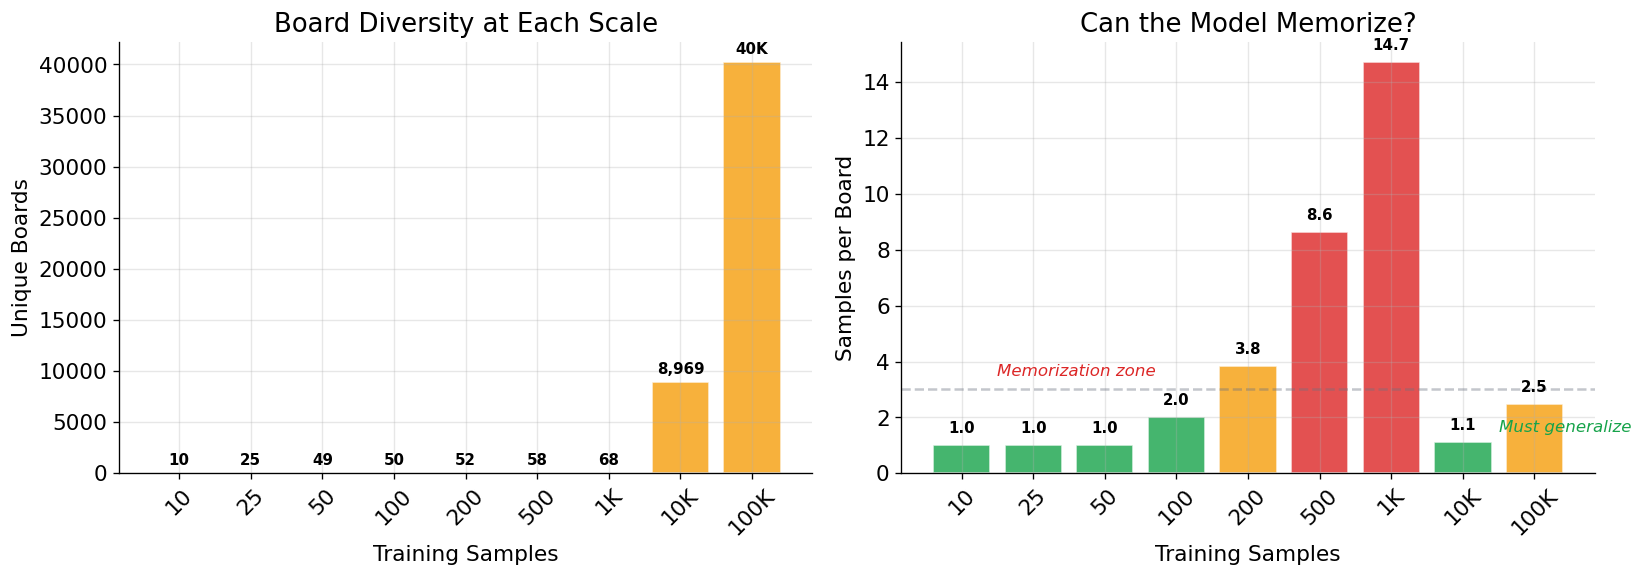

At 1K:   68 boards, 15 samples/board → memorize board patterns
At 100K: ~40,202 boards, 2.5 samples/board → must learn poker


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Left: Board diversity at different scales --
ax = axes[0]
scales = [10, 25, 50, 100, 200, 500, 1000, 10000, 100000]
M_boards = comb(52, 3) * 49 / 24  # ~45K structural equivalence classes

actual_boards = []
for s in scales:
    if s <= len(inputs):
        boards = set(tuple(np.round(inputs[i, :12], 4)) for i in range(s))
        actual_boards.append(len(boards))
    else:
        expected = M_boards * (1 - (1 - 1/M_boards)**s)
        actual_boards.append(int(expected))

samples_per_board = [s / b for s, b in zip(scales, actual_boards)]

bars = ax.bar(range(len(scales)), actual_boards,
              color=[C['blue'] if s <= 1000 else C['amber'] for s in scales],
              alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(scales)))
ax.set_xticklabels([f'{s//1000}K' if s >= 1000 else str(s) for s in scales], rotation=45)
ax.set_xlabel('Training Samples')
ax.set_ylabel('Unique Boards')
ax.set_title('Board Diversity at Each Scale')
for i, (s, b) in enumerate(zip(scales, actual_boards)):
    label = f'{b:,}' if b < 10000 else f'{b//1000:,}K'
    ax.text(i, b + max(actual_boards)*0.02, label, ha='center', fontsize=9, fontweight='bold')

# -- Right: Samples per board --
ax = axes[1]
bars = ax.bar(range(len(scales)), samples_per_board,
              color=[C['red'] if spb > 5 else C['amber'] if spb > 2 else C['green']
                     for spb in samples_per_board],
              alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(scales)))
ax.set_xticklabels([f'{s//1000}K' if s >= 1000 else str(s) for s in scales], rotation=45)
ax.set_xlabel('Training Samples')
ax.set_ylabel('Samples per Board')
ax.set_title('Can the Model Memorize?')
ax.axhline(y=3, color=C['gray'], linestyle='--', alpha=0.4)
ax.text(0.5, 3.5, 'Memorization zone', fontsize=10, color=C['red'], fontstyle='italic')
ax.text(7.5, 1.5, 'Must generalize', fontsize=10, color=C['green'], fontstyle='italic')
for i, spb in enumerate(samples_per_board):
    ax.text(i, spb + max(samples_per_board)*0.03, f'{spb:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

print(f"At 1K:   {n_unique_boards} boards, {1000/n_unique_boards:.0f} samples/board → memorize board patterns")
print(f"At 100K: ~{actual_boards[-1]:,} boards, {100000/actual_boards[-1]:.1f} samples/board → must learn poker")

## 3. What We Expect at 100K

**What we know:**
- The model architecture CAN learn — seen-board MSE drops 3x (0.25 → 0.08)
- It just can't generalize with only 68 boards — unseen-board MSE is flat
- Engine overhead is negligible (oracle locked-flop = 0.0003% over standard)
- Standard solver baseline exploitability: ~0.45%

**What 100K changes:**
- ~40K unique boards → memorization impossible → the model must learn poker structure
- With locked-flop solving, exploitability will finally reflect network quality
- The seen-board MSE of 0.08 becomes the realistic **floor** the model can approach

**What we'll measure:**
- MSE on held-out boards (should drop well below the current 0.24 plateau)
- Locked-flop exploitability (first meaningful measurement — target: single-digit %)